# Checkpoint Evaluation: PSNR / Chamfer / RL-DS

이미 저장된 `/home/carol/chaeyeon-kim/alpha26/logs/*.ckpt` 모델들을 다시 로드해서 validation set에 대해 평가합니다.

- `D_val^RL`: `validation_run_008.arrow`
- `D_val^DS`: `validation_run_024.arrow`
- RGB: PSNR, 높을수록 좋음
- LiDAR: Chamfer Distance, XYZ Euclidean Error, Range MAE, 낮을수록 좋음

결과는 `results/checkpoint_eval_metrics.csv`에 누적 저장됩니다. 중간에 끊겨도 같은 checkpoint/dataset/phase 조합은 건너뛰고 이어서 실행할 수 있습니다.


In [1]:
from pathlib import Path
import json
import math
import os
import re
import time
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)

ROOT = Path("/home/carol/chaeyeon-kim/alpha26")
TRAINER_NB = ROOT / "trainer11.ipynb"
LOG_DIR = ROOT / "logs"
PROCESSED_DIR = Path("/home/carol/chaeyeon-kim/processed")
RESULT_CSV = ROOT / "results" / "checkpoint_eval_metrics.csv"
FIG_DIR = ROOT / "results" / "checkpoint_eval_figures"
FIG_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2
NUM_WORKERS = 0

# 논문식 curve가 필요하면 'all'. 빠른 확인은 'latest' 또는 'last_n'.
CHECKPOINT_MODE = "all"  # 'all', 'latest', 'last_n'
LAST_N_CHECKPOINTS = 5
MAX_EVAL_BATCHES = 20      # trainer11.ipynb의 limit_val_batches=20과 맞춤. 전체 평가는 None.
MAX_CHAMFER_POINTS = 2048  # 느리면 512 또는 1024로 낮춰도 됩니다.
USE_AMP = DEVICE == "cuda"

VAL_DATASETS = {
    "RL": PROCESSED_DIR / "validation_run_008.arrow",
    "DS": PROCESSED_DIR / "validation_run_024.arrow",
}

print(f"device={DEVICE}, result_csv={RESULT_CSV}")


device=cuda, result_csv=/home/carol/chaeyeon-kim/alpha26/checkpoint_eval_metrics.csv


## 1. trainer11 정의 로드

`trainer11.ipynb`의 0-8번 셀만 실행해서 Dataset/Model/Trainer 정의를 가져옵니다. `main()` 학습 셀은 실행하지 않습니다. checkpoint를 로드할 예정이므로 timm backbone 생성 시 `pretrained=False`로 바꿔 외부 다운로드를 피합니다.

In [2]:
def load_trainer11_definitions():
    nb = json.loads(TRAINER_NB.read_text())
    namespace = {"__name__": "trainer11_eval_namespace"}
    for cell_idx in range(9):
        src = "".join(nb["cells"][cell_idx].get("source", []))
        src = src.replace("pretrained=True", "pretrained=False")
        exec(compile(src, f"{TRAINER_NB}:cell{cell_idx}", "exec"), namespace)
    return namespace

ns = load_trainer11_definitions()
cfg = ns["cfg"]
StreamWindowDataset = ns["StreamWindowDataset"]
WorldModelTrainer = ns["WorldModelTrainer"]

seq_len = cfg.RECEPTIVE_FIELD + cfg.FUTURE_HORIZON
stride = cfg.RECEPTIVE_FIELD
print(f"Loaded definitions. seq_len={seq_len}, stride={stride}, rf={cfg.RECEPTIVE_FIELD}, fh={cfg.FUTURE_HORIZON}")


Loaded definitions. seq_len=8, stride=4, rf=4, fh=4


## 2. 평가할 checkpoint 선택

In [3]:
def parse_step(path):
    match = re.search(r"step=(\d+)", path.name)
    return int(match.group(1)) if match else -1


def parse_epoch(path):
    match = re.search(r"epoch=(\d+)", path.name)
    return int(match.group(1)) if match else -1


def unique_step_checkpoints(log_dir):
    by_step = {}
    for ckpt in log_dir.glob("*.ckpt"):
        step = parse_step(ckpt)
        if step < 0:
            continue
        previous = by_step.get(step)
        if previous is None or ckpt.stat().st_mtime > previous.stat().st_mtime:
            by_step[step] = ckpt
    return [by_step[step] for step in sorted(by_step)]


ckpts = unique_step_checkpoints(LOG_DIR)
if CHECKPOINT_MODE == "latest":
    ckpts = ckpts[-1:]
elif CHECKPOINT_MODE == "last_n":
    ckpts = ckpts[-LAST_N_CHECKPOINTS:]
elif CHECKPOINT_MODE != "all":
    raise ValueError(f"Unknown CHECKPOINT_MODE: {CHECKPOINT_MODE}")

ckpt_df = pd.DataFrame([
    {
        "path": str(path),
        "file": path.name,
        "epoch": parse_epoch(path),
        "step": parse_step(path),
        "size_mb": path.stat().st_size / 1024 / 1024,
        "mtime": path.stat().st_mtime,
    }
    for path in ckpts
])

print(f"Selected {len(ckpt_df)} checkpoints.")
display(ckpt_df.tail(10))


Selected 36 checkpoints.


,path,file,epoch,step,size_mb,mtime
26,/home/carol/chaeyeon-kim/alpha26/logs/epoch=90...,epoch=90-step=27000.ckpt,90,27000,794.941046,1.777716e+09
27,/home/carol/chaeyeon-kim/alpha26/logs/epoch=93...,epoch=93-step=28000-v1.ckpt,93,28000,794.941046,1.777717e+09
28,/home/carol/chaeyeon-kim/alpha26/logs/epoch=96...,epoch=96-step=29000-v1.ckpt,96,29000,794.941046,1.777718e+09
29,/home/carol/chaeyeon-kim/alpha26/logs/epoch=10...,epoch=100-step=30000.ckpt,100,30000,794.941046,1.777718e+09
30,/home/carol/chaeyeon-kim/alpha26/logs/epoch=10...,epoch=103-step=31000-v1.ckpt,103,31000,794.941046,1.777719e+09
31,/home/carol/chaeyeon-kim/alpha26/logs/epoch=10...,epoch=107-step=32000.ckpt,107,32000,794.941046,1.777720e+09
32,/home/carol/chaeyeon-kim/alpha26/logs/epoch=11...,epoch=110-step=33000.ckpt,110,33000,794.941046,1.777721e+09
33,/home/carol/chaeyeon-kim/alpha26/logs/epoch=11...,epoch=113-step=34000-v1.ckpt,113,34000,794.941046,1.777721e+09
34,/home/carol/chaeyeon-kim/alpha26/logs/epoch=11...,epoch=117-step=35000.ckpt,117,35000,794.941046,1.777722e+09
35,/home/carol/chaeyeon-kim/alpha26/logs/epoch=12...,epoch=120-step=36000.ckpt,120,36000,794.941046,1.777723e+09


## 3. Dataset/DataLoader 준비

In [4]:
datasets = {}
dataloaders = {}
for name, arrow_path in VAL_DATASETS.items():
    if not arrow_path.exists():
        raise FileNotFoundError(arrow_path)
    ds = StreamWindowDataset(str(arrow_path), seq_len=seq_len, stride=stride, num_streams=BATCH_SIZE)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)
    datasets[name] = ds
    dataloaders[name] = loader
    print(f"{name}: {arrow_path.name}, windows={len(ds)}, batches={len(loader)}")


RL: validation_run_008.arrow, windows=598, batches=299
DS: validation_run_024.arrow, windows=898, batches=449


## 4. Metric 계산 함수

In [5]:
def load_model_from_checkpoint(ckpt_path):
    model = WorldModelTrainer(cfg=cfg, lr=1e-4, embedding_n_channels=128)
    model.metric_max_chamfer_points = MAX_CHAMFER_POINTS
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    state_dict = checkpoint["state_dict"] if "state_dict" in checkpoint else checkpoint
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing or unexpected:
        print(f"{Path(ckpt_path).name}: missing={len(missing)}, unexpected={len(unexpected)}")
    return model.to(DEVICE).eval(), checkpoint


def mean_dicts(dicts):
    if not dicts:
        return {}
    keys = sorted(set().union(*[d.keys() for d in dicts]))
    out = {}
    for key in keys:
        values = [d[key] for d in dicts if key in d and np.isfinite(d[key])]
        out[key] = float(np.mean(values)) if values else np.nan
    return out


def tensor_dict_to_float(metric_dict):
    out = {}
    for key, value in metric_dict.items():
        if torch.is_tensor(value):
            value = value.detach().float().cpu().item()
        out[key] = float(value)
    return out


@torch.no_grad()
def evaluate_model_on_loader(model, loader, max_batches=MAX_EVAL_BATCHES):
    loss_rows = []
    obs_metric_rows = []
    future_metric_rows = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        batch = {key: value.to(DEVICE) if torch.is_tensor(value) else value for key, value in batch.items()}
        batch = model.prepare_custom_batch(batch)

        amp_context = torch.autocast(device_type=DEVICE, dtype=torch.float16) if USE_AMP else nullcontext()
        with amp_context:
            losses, output, state_dict, losses_imagine, output_imagine = model._observe_and_imagine(batch)

        loss_values = tensor_dict_to_float(losses)
        loss_values["loss"] = float(sum(loss_values.values()))
        loss_rows.append(loss_values)

        batch_rf = model._slice_batch(batch, 0, model.rf)
        obs_metric_rows.append(tensor_dict_to_float(model.compute_eval_metrics(batch_rf, output)))

        if output_imagine is not None and model.fh > 0:
            batch_fh = model._slice_batch(batch, model.rf, model.rf + model.fh)
            future_metric_rows.append(tensor_dict_to_float(model.compute_eval_metrics(batch_fh, output_imagine, prefix="future_")))

    return {
        "loss": mean_dicts(loss_rows),
        "observed": mean_dicts(obs_metric_rows),
        "future": mean_dicts(future_metric_rows),
        "num_batches": len(loss_rows),
    }


def flatten_eval_result(result):
    flat = {"num_batches": result["num_batches"]}
    for key, value in result["loss"].items():
        flat[f"loss_{key}"] = value
    for key, value in result["observed"].items():
        flat[f"observed_{key}"] = value
    for key, value in result["future"].items():
        flat[f"future_{key}"] = value
    return flat


## 5. Checkpoint 평가 실행

시간이 오래 걸릴 수 있습니다. GPU 기준으로도 checkpoint 수 x RL/DS x batch 수만큼 inference가 돕니다. 빠르게 확인하려면 위 설정 셀에서 `CHECKPOINT_MODE='latest'` 또는 `MAX_EVAL_BATCHES=2`로 바꾸고 다시 실행하세요.

In [6]:
existing = pd.read_csv(RESULT_CSV) if RESULT_CSV.exists() else pd.DataFrame()
done = set()
if not existing.empty:
    done = set(zip(existing["step"], existing["dataset"]))
    print(f"Loaded existing results: {len(existing)} rows")

rows = []
start_time = time.time()

for ckpt_idx, row in ckpt_df.iterrows():
    ckpt_path = Path(row["path"])
    step = int(row["step"])
    needed_datasets = [name for name in dataloaders if (step, name) not in done]
    if not needed_datasets:
        print(f"[{ckpt_idx + 1}/{len(ckpt_df)}] step={step}: already evaluated")
        continue

    print(f"[{ckpt_idx + 1}/{len(ckpt_df)}] loading {ckpt_path.name}")
    model, checkpoint = load_model_from_checkpoint(ckpt_path)

    for dataset_name in needed_datasets:
        print(f"  evaluating {dataset_name}...", end=" " if os.name != "nt" else "\n")
        result = evaluate_model_on_loader(model, dataloaders[dataset_name], max_batches=MAX_EVAL_BATCHES)
        out = {
            "checkpoint": ckpt_path.name,
            "checkpoint_path": str(ckpt_path),
            "epoch": int(row["epoch"]),
            "step": step,
            "dataset": dataset_name,
            "global_step": int(checkpoint.get("global_step", step)) if isinstance(checkpoint, dict) else step,
        }
        out.update(flatten_eval_result(result))
        rows.append(out)
        print(f"done, batches={result['num_batches']}")

        combined = pd.concat([existing, pd.DataFrame(rows)], ignore_index=True)
        combined = combined.drop_duplicates(subset=["step", "dataset"], keep="last").sort_values(["step", "dataset"])
        combined.to_csv(RESULT_CSV, index=False)

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

elapsed_min = (time.time() - start_time) / 60
metrics_df = pd.read_csv(RESULT_CSV).sort_values(["step", "dataset"])
print(f"Finished/updated {RESULT_CSV}. elapsed={elapsed_min:.1f} min, rows={len(metrics_df)}")
display(metrics_df.tail())


[1/36] loading epoch=3-step=1000-v1.ckpt
  evaluating RL... done, batches=20
  evaluating DS... done, batches=20
[2/36] loading epoch=6-step=2000-v1.ckpt
  evaluating RL... done, batches=20
  evaluating DS... done, batches=20
[3/36] loading epoch=10-step=3000.ckpt
  evaluating RL... done, batches=20
  evaluating DS... done, batches=20
[4/36] loading epoch=13-step=4000-v1.ckpt
  evaluating RL... done, batches=20
  evaluating DS... done, batches=20
[5/36] loading epoch=16-step=5000-v1.ckpt
  evaluating RL... done, batches=20
  evaluating DS... done, batches=20
[6/36] loading epoch=20-step=6000.ckpt
  evaluating RL... done, batches=20
  evaluating DS... done, batches=20
[7/36] loading epoch=23-step=7000-v1.ckpt
  evaluating RL... done, batches=20
  evaluating DS... done, batches=20
[8/36] loading epoch=26-step=8000-v1.ckpt
  evaluating RL... done, batches=20
  evaluating DS... done, batches=20
[9/36] loading epoch=30-step=9000.ckpt
  evaluating RL... done, batches=20
  evaluating DS... do

,checkpoint,checkpoint_path,epoch,step,dataset,global_step,num_batches,loss_future_lidar_depth_2,loss_future_lidar_depth_4,loss_future_lidar_empty_depth_2,loss_future_lidar_empty_depth_4,loss_future_lidar_xyz_2,loss_future_lidar_xyz_4,loss_future_rgb_2,loss_future_rgb_4,loss_lidar_depth_2,loss_lidar_depth_4,loss_lidar_empty_depth_2,loss_lidar_empty_depth_4,loss_lidar_xyz_2,loss_lidar_xyz_4,loss_loss,loss_probabilistic,loss_rgb_2,loss_rgb_4,observed_lidar_chamfer_xyz,observed_lidar_range_mae,observed_lidar_xyz_euclidean,observed_rgb_psnr,future_future_lidar_chamfer_xyz,future_future_lidar_range_mae,future_future_lidar_xyz_euclidean,future_future_rgb_psnr
67,epoch=113-step=34000-v1.ckpt,/home/carol/chaeyeon-kim/alpha26/logs/epoch=11...,113,34000,RL,34000,20,2.819699,1.530047,0.279810,0.132191,21.915096,11.562712,0.013050,0.006484,2.656902,1.443597,0.277963,0.129775,19.648303,10.291279,72.991049,0.263914,0.013529,0.006699,2.601413,5.313804,5.751346,9.590341,2.581248,5.639397,6.025384,9.898101
68,epoch=117-step=35000.ckpt,/home/carol/chaeyeon-kim/alpha26/logs/epoch=11...,117,35000,DS,35000,20,3.419062,1.803185,0.308749,0.141019,29.051308,14.879362,0.011987,0.006028,3.212471,1.702734,0.289979,0.130741,26.314307,13.533452,95.040042,0.217837,0.011874,0.005946,2.287970,6.424943,7.034264,10.161936,2.288388,6.838124,7.323225,9.920383
69,epoch=117-step=35000.ckpt,/home/carol/chaeyeon-kim/alpha26/logs/epoch=11...,117,35000,RL,35000,20,2.998338,1.618286,0.305071,0.141161,23.815605,12.412392,0.013265,0.006732,2.956777,1.603838,0.286907,0.128925,23.812543,12.471561,82.925578,0.334792,0.012897,0.006487,2.544351,5.913555,6.510969,9.674764,2.457573,5.996676,6.372728,9.379811
70,epoch=120-step=36000.ckpt,/home/carol/chaeyeon-kim/alpha26/logs/epoch=12...,120,36000,DS,36000,20,2.679755,1.438504,0.292035,0.139125,17.264549,9.312880,0.010783,0.005323,2.682477,1.437726,0.283111,0.133565,17.400270,9.350087,62.615541,0.168984,0.010953,0.005415,2.287473,5.364955,5.797627,11.145213,2.267145,5.359510,5.735467,11.272238
71,epoch=120-step=36000.ckpt,/home/carol/chaeyeon-kim/alpha26/logs/epoch=12...,120,36000,RL,36000,20,2.663878,1.441852,0.288841,0.139851,18.990500,9.998599,0.012893,0.006348,2.593432,1.407427,0.280199,0.132601,18.595089,9.823929,66.649005,0.254551,0.012748,0.006267,2.659127,5.186864,5.627489,9.978193,2.701650,5.327757,5.635073,9.968421


## 6. 결과 로드 및 요약

In [7]:
metrics_df = pd.read_csv(RESULT_CSV).sort_values(["step", "dataset"])
metric_cols = [col for col in metrics_df.columns if col.startswith(("observed_", "future_", "loss_"))]
print(f"rows={len(metrics_df)}, steps={metrics_df['step'].nunique()}, datasets={metrics_df['dataset'].unique().tolist()}")
display(metrics_df[["step", "dataset", "num_batches"] + metric_cols].tail(10))

summary_cols = [
    "observed_rgb_psnr",
    "future_future_rgb_psnr",
    "observed_lidar_chamfer_xyz",
    "future_future_lidar_chamfer_xyz",
    "observed_lidar_xyz_euclidean",
    "observed_lidar_range_mae",
]
summary_cols = [col for col in summary_cols if col in metrics_df.columns]
display(metrics_df.groupby("dataset")[summary_cols].agg(["mean", "min", "max"]))


rows=72, steps=36, datasets=['DS', 'RL']


,step,dataset,num_batches,loss_future_lidar_depth_2,loss_future_lidar_depth_4,loss_future_lidar_empty_depth_2,loss_future_lidar_empty_depth_4,loss_future_lidar_xyz_2,loss_future_lidar_xyz_4,loss_future_rgb_2,loss_future_rgb_4,loss_lidar_depth_2,loss_lidar_depth_4,loss_lidar_empty_depth_2,loss_lidar_empty_depth_4,loss_lidar_xyz_2,loss_lidar_xyz_4,loss_loss,loss_probabilistic,loss_rgb_2,loss_rgb_4,observed_lidar_chamfer_xyz,observed_lidar_range_mae,observed_lidar_xyz_euclidean,observed_rgb_psnr,future_future_lidar_chamfer_xyz,future_future_lidar_range_mae,future_future_lidar_xyz_euclidean,future_future_rgb_psnr
62,32000,DS,20,3.119299,1.647737,0.317666,0.143187,25.507990,12.801382,0.011467,0.005678,2.960520,1.574830,0.298207,0.132438,23.345286,11.893791,84.057093,0.280211,0.011652,0.005751,2.247834,5.921039,6.813079,10.536937,2.269006,6.238598,7.052275,10.685062
63,32000,RL,20,2.636945,1.417253,0.319733,0.143438,19.264277,9.823778,0.013101,0.006493,2.654441,1.434979,0.301383,0.132830,19.704964,10.272085,68.562218,0.416996,0.013068,0.006453,2.467651,5.308883,6.139273,9.753447,2.395034,5.273890,5.969483,9.813255
64,33000,DS,20,2.740531,1.497244,0.287107,0.134632,18.424989,10.082584,0.011078,0.005476,2.745268,1.497399,0.269594,0.125226,19.505598,10.550918,68.079579,0.184096,0.011937,0.005903,2.302607,5.490536,6.217816,10.349193,2.264124,5.481062,6.010533,10.922486
65,33000,RL,20,2.688057,1.453382,0.289649,0.135984,18.648607,9.813864,0.013213,0.006540,2.691686,1.457804,0.274677,0.126126,20.326331,10.683863,68.910297,0.279721,0.013913,0.006879,2.723273,5.383371,6.145946,9.203666,2.697765,5.376115,5.799075,9.755815
66,34000,DS,20,3.069579,1.670269,0.276971,0.130997,23.515302,12.888823,0.011231,0.005585,2.840940,1.553144,0.269570,0.127390,20.462005,11.133798,78.146005,0.172346,0.012062,0.005993,2.328089,5.681880,6.140050,10.377614,2.357541,6.139158,6.593593,10.846772
67,34000,RL,20,2.819699,1.530047,0.279810,0.132191,21.915096,11.562712,0.013050,0.006484,2.656902,1.443597,0.277963,0.129775,19.648303,10.291279,72.991049,0.263914,0.013529,0.006699,2.601413,5.313804,5.751346,9.590341,2.581248,5.639397,6.025384,9.898101
68,35000,DS,20,3.419062,1.803185,0.308749,0.141019,29.051308,14.879362,0.011987,0.006028,3.212471,1.702734,0.289979,0.130741,26.314307,13.533452,95.040042,0.217837,0.011874,0.005946,2.287970,6.424943,7.034264,10.161936,2.288388,6.838124,7.323225,9.920383
69,35000,RL,20,2.998338,1.618286,0.305071,0.141161,23.815605,12.412392,0.013265,0.006732,2.956777,1.603838,0.286907,0.128925,23.812543,12.471561,82.925578,0.334792,0.012897,0.006487,2.544351,5.913555,6.510969,9.674764,2.457573,5.996676,6.372728,9.379811
70,36000,DS,20,2.679755,1.438504,0.292035,0.139125,17.264549,9.312880,0.010783,0.005323,2.682477,1.437726,0.283111,0.133565,17.400270,9.350087,62.615541,0.168984,0.010953,0.005415,2.287473,5.364955,5.797627,11.145213,2.267145,5.359510,5.735467,11.272238
71,36000,RL,20,2.663878,1.441852,0.288841,0.139851,18.990500,9.998599,0.012893,0.006348,2.593432,1.407427,0.280199,0.132601,18.595089,9.823929,66.649005,0.254551,0.012748,0.006267,2.659127,5.186864,5.627489,9.978193,2.701650,5.327757,5.635073,9.968421


observed_rgb_psnr                      future_future_rgb_psnr   
                     mean       min        max                   mean   
dataset                                                                 
DS              10.545677  8.655443  11.691054              10.795302  \
RL              10.066794  8.571778  10.851802              10.136913   

                             observed_lidar_chamfer_xyz                       
              min        max                       mean       min       max   
dataset                                                                       
DS       8.680748  11.963869                   2.284512  2.119712  2.963245  \
RL       8.496191  11.112626                   2.713924  2.467651  3.272030   

        future_future_lidar_chamfer_xyz                       
                                   mean       min       max   
dataset                                                       
DS                             2.251682  2.110402  2.588519  \
RL                             2.659824  2.395034  2.953127   

        observed_lidar_xyz_euclidean                       
                                mean       min       max   
dataset                                                    
DS                          5.761432  4.905585  7.106332  \
RL                          5.690528  5.000973  7.256477   

        observed_lidar_range_mae                      
                            mean       min       max  
dataset                                               
DS                      5.089231  4.410365  6.436148  
RL                      5.185573  4.703729  6.430941

## 7. Loss / Metric 그래프

Saved: /home/carol/chaeyeon-kim/alpha26/checkpoint_eval_figures/checkpoint_eval_overview.png


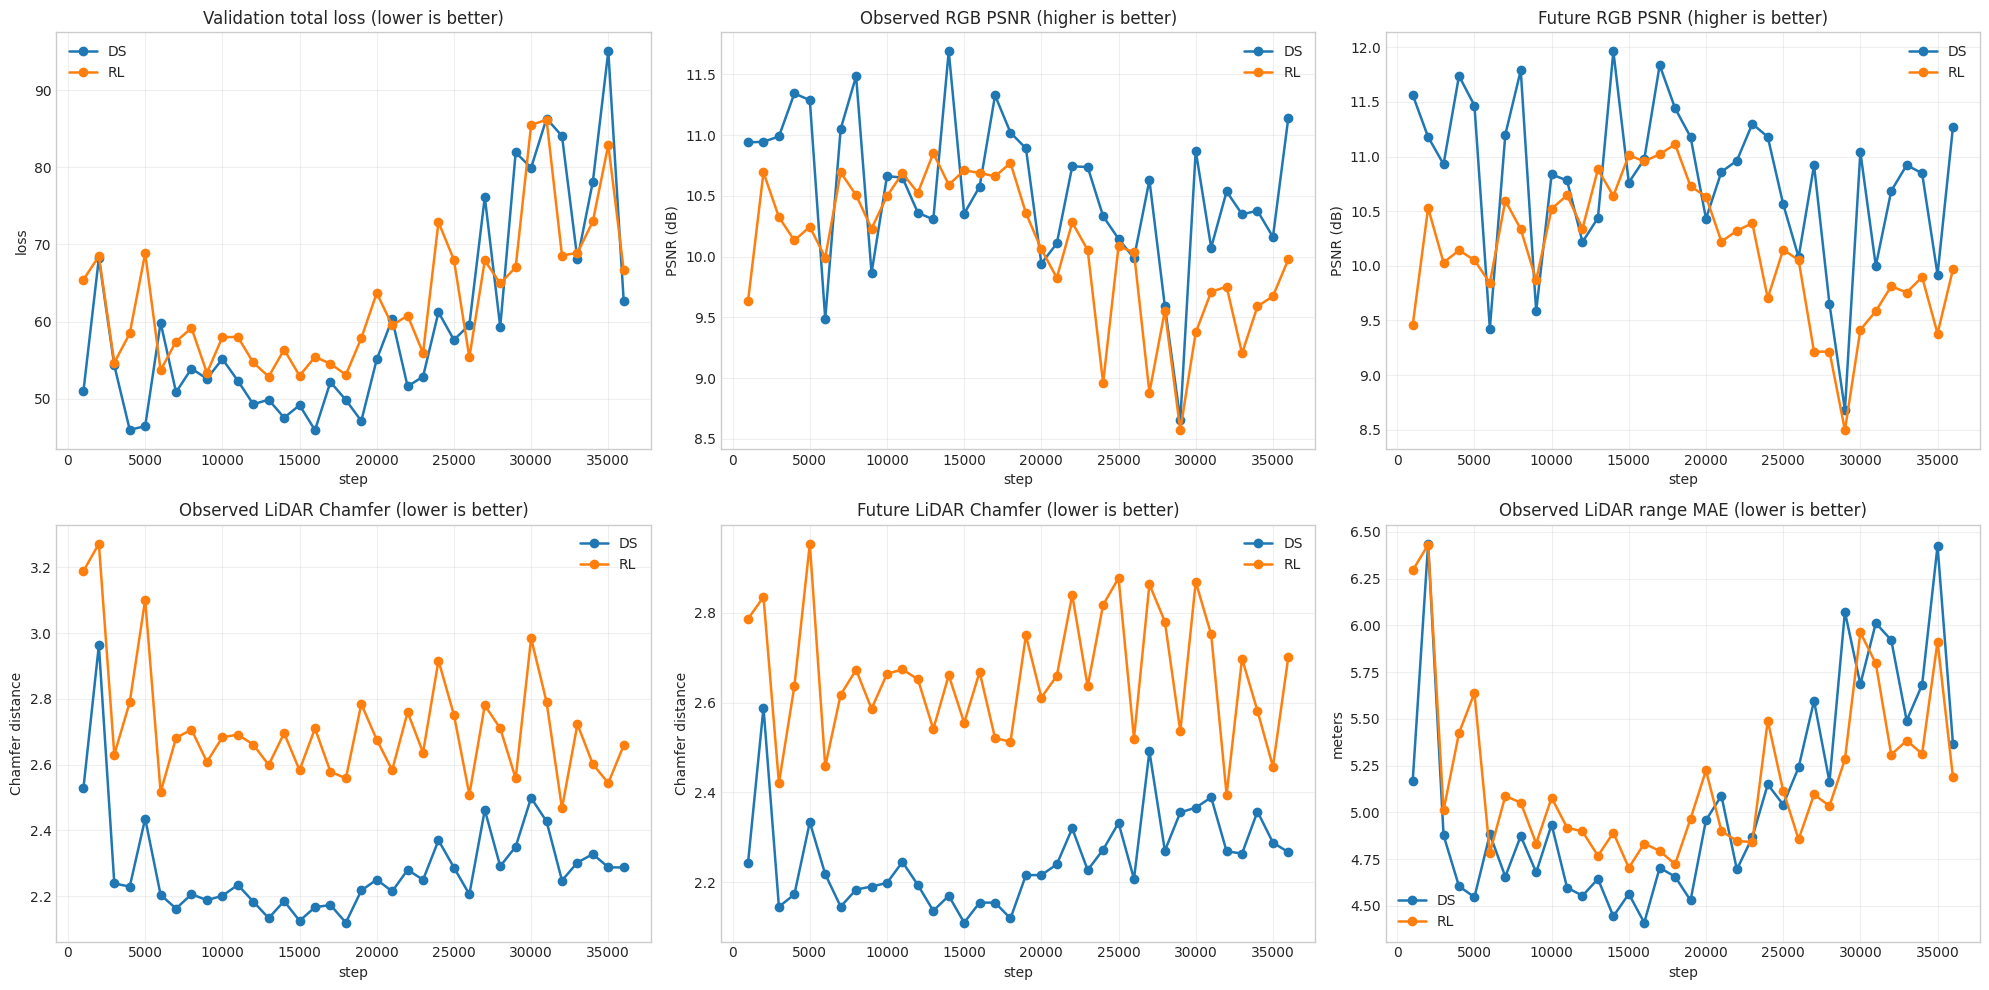

In [8]:
def plot_metric_curve(ax, data, column, title, ylabel, higher_is_better=None):
    if column not in data.columns:
        ax.text(0.5, 0.5, f"Missing column\n{column}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        ax.axis("off")
        return
    for dataset_name, group in data.groupby("dataset"):
        group = group.sort_values("step")
        ax.plot(group["step"], group[column], marker="o", linewidth=1.8, label=dataset_name)
    suffix = ""
    if higher_is_better is True:
        suffix = " (higher is better)"
    elif higher_is_better is False:
        suffix = " (lower is better)"
    ax.set_title(title + suffix)
    ax.set_xlabel("step")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 3, figsize=(20, 10))
plot_metric_curve(axes[0, 0], metrics_df, "loss_loss", "Validation total loss", "loss", False)
plot_metric_curve(axes[0, 1], metrics_df, "observed_rgb_psnr", "Observed RGB PSNR", "PSNR (dB)", True)
plot_metric_curve(axes[0, 2], metrics_df, "future_future_rgb_psnr", "Future RGB PSNR", "PSNR (dB)", True)
plot_metric_curve(axes[1, 0], metrics_df, "observed_lidar_chamfer_xyz", "Observed LiDAR Chamfer", "Chamfer distance", False)
plot_metric_curve(axes[1, 1], metrics_df, "future_future_lidar_chamfer_xyz", "Future LiDAR Chamfer", "Chamfer distance", False)
plot_metric_curve(axes[1, 2], metrics_df, "observed_lidar_range_mae", "Observed LiDAR range MAE", "meters", False)
plt.tight_layout()
out = FIG_DIR / "checkpoint_eval_overview.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()


## 8. MUVO Figure 스타일 4-panel

Saved: /home/carol/chaeyeon-kim/alpha26/checkpoint_eval_figures/muvo_style_rl_ds_panels.png


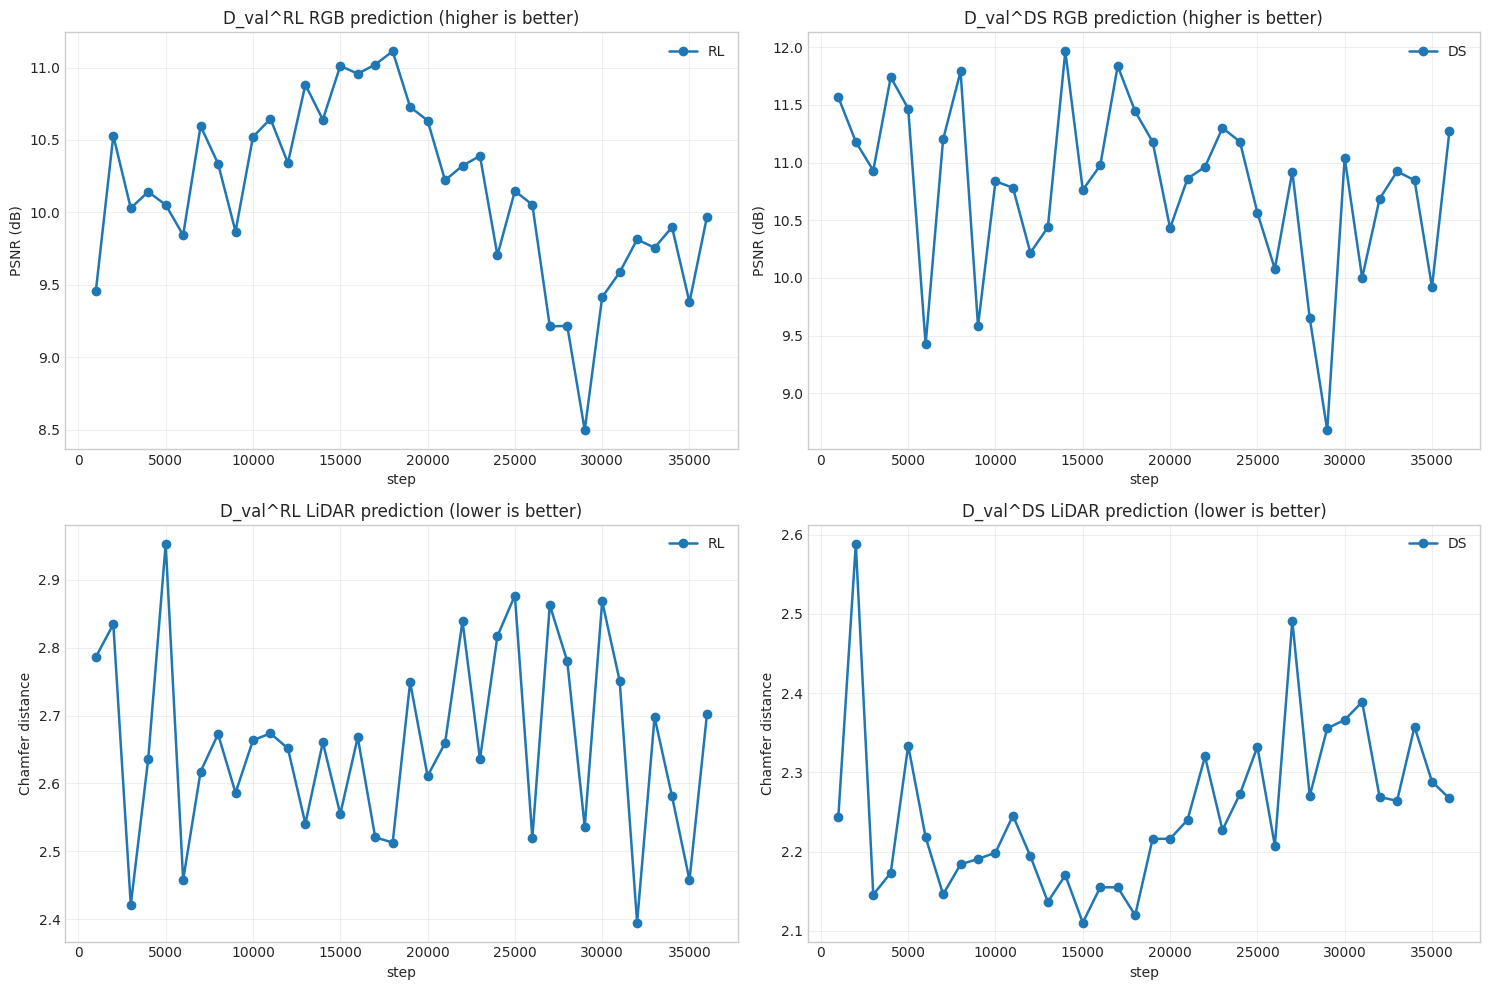

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_metric_curve(axes[0, 0], metrics_df[metrics_df["dataset"].eq("RL")], "future_future_rgb_psnr", "D_val^RL RGB prediction", "PSNR (dB)", True)
plot_metric_curve(axes[0, 1], metrics_df[metrics_df["dataset"].eq("DS")], "future_future_rgb_psnr", "D_val^DS RGB prediction", "PSNR (dB)", True)
plot_metric_curve(axes[1, 0], metrics_df[metrics_df["dataset"].eq("RL")], "future_future_lidar_chamfer_xyz", "D_val^RL LiDAR prediction", "Chamfer distance", False)
plot_metric_curve(axes[1, 1], metrics_df[metrics_df["dataset"].eq("DS")], "future_future_lidar_chamfer_xyz", "D_val^DS LiDAR prediction", "Chamfer distance", False)
plt.tight_layout()
out = FIG_DIR / "muvo_style_rl_ds_panels.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()


## 9. 최신 checkpoint 결과만 보기

In [10]:
latest_step = metrics_df["step"].max()
latest_df = metrics_df[metrics_df["step"].eq(latest_step)].copy()
cols = [
    "step", "dataset", "num_batches",
    "loss_loss",
    "observed_rgb_psnr", "future_future_rgb_psnr",
    "observed_lidar_chamfer_xyz", "future_future_lidar_chamfer_xyz",
    "observed_lidar_xyz_euclidean", "future_future_lidar_xyz_euclidean",
    "observed_lidar_range_mae", "future_future_lidar_range_mae",
]
cols = [col for col in cols if col in latest_df.columns]
display(latest_df[cols])


,step,dataset,num_batches,loss_loss,observed_rgb_psnr,future_future_rgb_psnr,observed_lidar_chamfer_xyz,future_future_lidar_chamfer_xyz,observed_lidar_xyz_euclidean,future_future_lidar_xyz_euclidean,observed_lidar_range_mae,future_future_lidar_range_mae
70,36000,DS,20,62.615541,11.145213,11.272238,2.287473,2.267145,5.797627,5.735467,5.364955,5.359510
71,36000,RL,20,66.649005,9.978193,9.968421,2.659127,2.701650,5.627489,5.635073,5.186864,5.327757


## 팀 공유용 평가 결과 요약

### 평가 설정

- 저장된 checkpoint 36개를 다시 로드해서 평가했습니다. 평가 step 범위는 `1000`부터 `36000`까지입니다.
- 각 checkpoint는 validation dataset 2개에서 평가했습니다.
  - `Val-A`: `validation_run_008.arrow` (노트북/CSV의 `RL`)
  - `Val-B`: `validation_run_024.arrow` (노트북/CSV의 `DS`)
- 여기서 `Val-B`는 극한 날씨 domain shift로 해석하지 않고, 별도 validation run으로만 봅니다.
- 현재 결과는 각 validation run에서 `20 batches`만 사용한 빠른 평가입니다. 최종 보고용 수치는 `MAX_EVAL_BATCHES = None`으로 전체 validation을 다시 평가하는 것이 더 안전합니다.

### 사용한 지표

- RGB 예측 품질: `PSNR`, 높을수록 좋습니다.
- LiDAR 예측 품질: `Chamfer Distance`, 낮을수록 좋습니다.
- 보조 LiDAR 지표: `XYZ Euclidean Error`, `Range MAE`, 둘 다 낮을수록 좋습니다.
- 그래프는 `results/checkpoint_eval_figures/` 아래에 저장했습니다.

### 최신 checkpoint 결과 (`step=36000`)

| Validation | Future RGB PSNR ↑ | Future LiDAR Chamfer ↓ | Total Loss ↓ |
|---|---:|---:|---:|
| Val-A (`RL`) | 9.968 | 2.702 | 66.649 |
| Val-B (`DS`) | 11.272 | 2.267 | 62.616 |

### Metric별 best checkpoint

| 기준 | Val-A (`RL`) | Val-B (`DS`) |
|---|---:|---:|
| Future RGB PSNR 최고 | step 18000 / 11.113 | step 14000 / 11.964 |
| Future LiDAR Chamfer 최저 | step 32000 / 2.395 | step 15000 / 2.110 |
| Total Loss 최저 | step 13000 / 52.862 | step 16000 / 45.929 |

### 해석

- 최신 checkpoint인 `step=36000`이 모든 지표에서 최고는 아닙니다. 학습 후반부로 갈수록 성능이 계속 좋아지기보다는 metric이 흔들리는 패턴이 있습니다.
- RGB PSNR은 대체로 중반 checkpoint에서 더 좋게 나옵니다. Val-A 기준 best는 `step=18000`, Val-B 기준 best는 `step=14000`입니다.
- LiDAR Chamfer는 Val-A에서는 `step=32000`, Val-B에서는 `step=15000`이 가장 좋습니다.
- RGB PSNR, LiDAR Chamfer, Range MAE를 함께 본 단순 composite 기준으로는 전체 평균 best가 `step=17000`입니다. 대표 checkpoint 하나를 고른다면 `step=17000` 근처를 우선 검토하는 것이 좋습니다.

### 주의 사항

- `Val-A`와 `Val-B`는 서로 다른 validation run이므로, 두 값의 차이를 domain shift 성능 차이로 해석하면 안 됩니다.
- 현재 평가는 빠른 확인용 20 batch 결과입니다. 최종 표나 발표 자료에 넣기 전에는 전체 validation으로 재평가하는 것을 권장합니다.
